# 02 · Análisis exploratorio con Python

**Objetivo del notebook:** revisar nulos, temporalidad, montos y variables de conteo para decidir qué entra al pipeline del modelo, y comprobar el comportamiento de las variables construidas en SQL.

La tasa de nulos de las 434 columnas se calcula dentro de SQLite y solo se traen a memoria las columnas que se grafican, en lugar de cargar la base completa.

In [1]:
# ----------------------------------
# Conexión y carga de datos
# ----------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from fraude import base_datos as bd, datos, graficos
warnings.filterwarnings('ignore')

graficos.estilo()
pd.set_option('display.max_columns', 50)

conn = bd.conectar()
datos.crear_features(conn)   # crea la tabla si el notebook 01 no se ha ejecutado

# Porcentaje de nulos de cada columna sobre la unión transacciones-identidad, en SQL
nulos = datos.tasa_nulos(conn)

# Columnas que se analizan en este notebook, más las variables SQL de comportamiento
c_cols = [f'C{i}' for i in range(1, 15)]
df = datos.cargar_datos(conn, columnas_transacciones=['TransactionAmt'] + c_cols)
conn.close()

print(f"Dataset unificado: {df.shape[0]:,} filas x {len(nulos) + 1} columnas")
print(f"Columnas cargadas para el EDA: {df.shape[1]}")
print(f"Tasa de fraude: {df['isFraud'].mean()*100:.2f}%")

Dataset unificado: 590,540 filas x 434 columnas
Columnas cargadas para el EDA: 27
Tasa de fraude: 3.50%


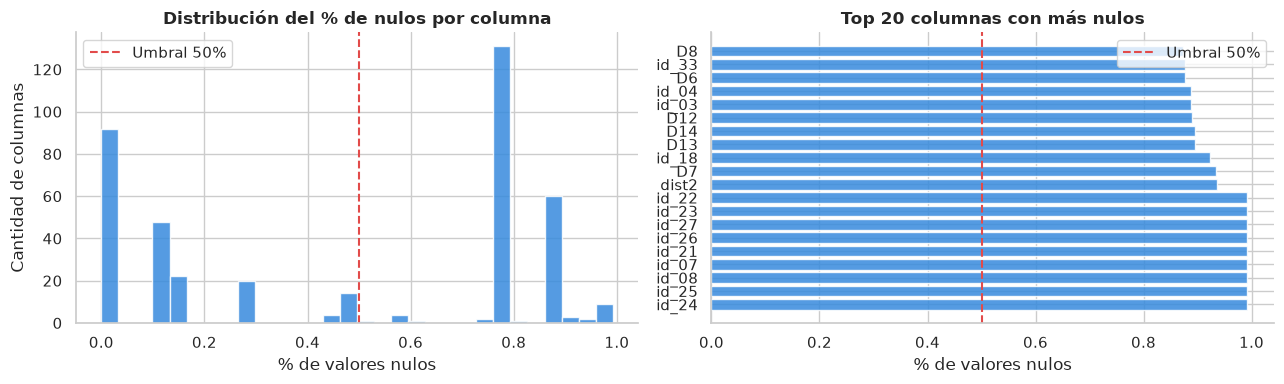

Columnas excluidas por >50% nulos: 214
Columnas conservadas: 220
  de las excluidas, columnas de la tabla identity: 40 de 40


In [2]:
# -----------------------------------------------------------
# Análisis de nulos
# Porcentaje de nulos por columna
# Columnas con más del 50% de nulos se excluirán del pipeline
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nulos[nulos > 0], bins=30, color=graficos.AZUL, alpha=0.85)
axes[0].axvline(0.5, color=graficos.ROJO, linestyle='--', lw=1.5,
                label='Umbral 50%')
axes[0].set_title('Distribución del % de nulos por columna')
axes[0].set_xlabel('% de valores nulos')
axes[0].set_ylabel('Cantidad de columnas')
axes[0].legend()
sns.despine(ax=axes[0])

axes[1].barh(nulos.head(20).index,
             nulos.head(20).values,
             color=graficos.AZUL, alpha=0.85)
axes[1].axvline(0.5, color=graficos.ROJO, linestyle='--', lw=1.5,
                label='Umbral 50%')
axes[1].set_title('Top 20 columnas con más nulos')
axes[1].set_xlabel('% de valores nulos')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
graficos.guardar(fig, '02_nulos')
plt.show()

cols_excluir = nulos[nulos > 0.5].index.tolist()
print(f"Columnas excluidas por >50% nulos: {len(cols_excluir)}")
print(f"Columnas conservadas: {len(nulos) + 1 - len(cols_excluir)}")
identidad = [c for c in cols_excluir if c.startswith('id_') or c.startswith('Device')]
print(f"  de las excluidas, columnas de la tabla identity: {len(identidad)} de 40")

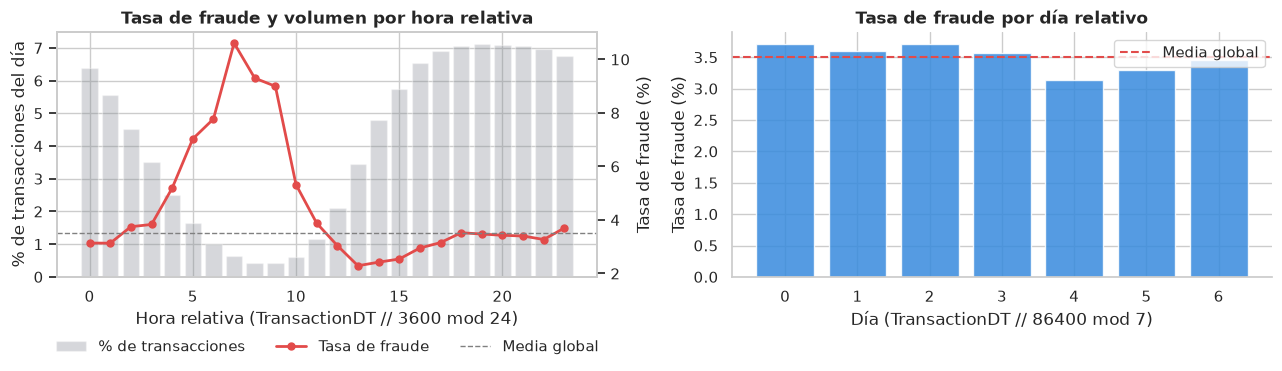

Horas con menor volumen:
      pct_transacciones  tasa_fraude_pct
hora                                    
9                  0.42             9.00
8                  0.44             9.30
10                 0.61             5.32
7                  0.63            10.61
6                  1.02             7.77

Tasa por día: mínimo 3.15% y máximo 3.72%


In [3]:
# --------------------------------------------------------------------------
# Análisis temporal
# TransactionDT es un delta en segundos desde un punto de referencia desconocido,
# por lo que la hora y el día son relativos a esa referencia y no al reloj local.
# Se grafica también el volumen para ubicar las horas de baja actividad.
# --------------------------------------------------------------------------

df['hora'] = (df['TransactionDT'] // 3600) % 24
df['dia_semana'] = (df['TransactionDT'] // 86400) % 7

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

volumen_hora = df['hora'].value_counts(normalize=True).sort_index() * 100
tasa_hora = df.groupby('hora')['isFraud'].mean() * 100

axes[0].bar(volumen_hora.index, volumen_hora.values, color=graficos.GRIS, alpha=0.35,
            label='% de transacciones')
axes[0].set_ylabel('% de transacciones del día')
eje_tasa = axes[0].twinx()
eje_tasa.plot(tasa_hora.index, tasa_hora.values,
              marker='o', color=graficos.ROJO, lw=2, markersize=5, label='Tasa de fraude')
eje_tasa.axhline(df['isFraud'].mean()*100, color='gray',
                 linestyle='--', lw=1, label='Media global')
eje_tasa.set_ylabel('Tasa de fraude (%)')
eje_tasa.grid(False)
axes[0].set_title('Tasa de fraude y volumen por hora relativa')
axes[0].set_xlabel('Hora relativa (TransactionDT // 3600 mod 24)')
lineas = axes[0].get_legend_handles_labels()
lineas_tasa = eje_tasa.get_legend_handles_labels()
axes[0].legend(lineas[0] + lineas_tasa[0], lineas[1] + lineas_tasa[1],
               loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)

tasa_dia = df.groupby('dia_semana')['isFraud'].mean() * 100
axes[1].bar(tasa_dia.index, tasa_dia.values,
            color=graficos.AZUL, alpha=0.85)
axes[1].axhline(df['isFraud'].mean()*100, color=graficos.ROJO,
                linestyle='--', lw=1.5, label='Media global')
axes[1].set_title('Tasa de fraude por día relativo')
axes[1].set_xlabel('Día (TransactionDT // 86400 mod 7)')
axes[1].set_ylabel('Tasa de fraude (%)')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
graficos.guardar(fig, '02_temporalidad')
plt.show()

resumen_hora = pd.DataFrame({'pct_transacciones': volumen_hora.round(2), 'tasa_fraude_pct': tasa_hora.round(2)})
print("Horas con menor volumen:")
print(resumen_hora.sort_values('pct_transacciones').head(5).to_string())
print(f"\nTasa por día: mínimo {tasa_dia.min():.2f}% y máximo {tasa_dia.max():.2f}%")

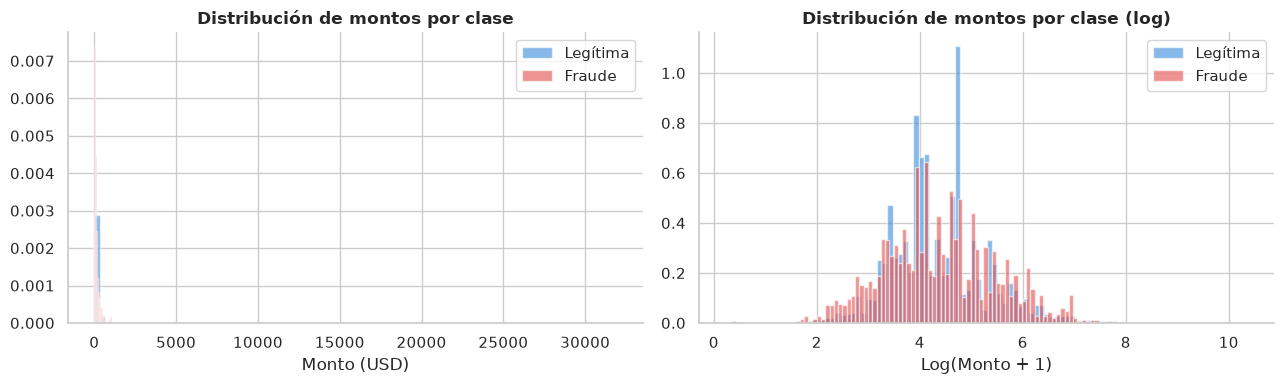

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00

% de transacciones de cada clase por tramo de monto:
isFraud            0     1
TransactionAmt            
< $32           16.1  22.2
$32 a $402      78.4  69.7
> $402           5.5   8.1

Montos más repetidos en legítimas:
TransactionAmt
59.00     5.3
117.00    5.0
107.95    4.2


In [4]:
# --------------------------------------------------------------------
# Distribución de TransactionAmt por clase
# Se usa escala logarítmica para manejo de la asimetría de la variable
# --------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for clase, color, label in [(0, graficos.AZUL, 'Legítima'),
                             (1, graficos.ROJO, 'Fraude')]:
    axes[0].hist(df[df['isFraud'] == clase]['TransactionAmt'],
                 bins=100, alpha=0.6, color=color,
                 label=label, density=True)
axes[0].set_title('Distribución de montos por clase')
axes[0].set_xlabel('Monto (USD)')
axes[0].legend()
sns.despine(ax=axes[0])

for clase, color, label in [(0, graficos.AZUL, 'Legítima'),
                             (1, graficos.ROJO, 'Fraude')]:
    axes[1].hist(np.log1p(df[df['isFraud'] == clase]['TransactionAmt']),
                 bins=100, alpha=0.6, color=color,
                 label=label, density=True)
axes[1].set_title('Distribución de montos por clase (log)')
axes[1].set_xlabel('Log(Monto + 1)')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
graficos.guardar(fig, '02_montos')
plt.show()

print(df.groupby('isFraud')['TransactionAmt'].describe(percentiles=[0.25, 0.5, 0.75]).round(2).to_string())

# Cortes en log 3.5 y log 6 (aprox. $32 y $402) para comparar las colas de cada clase
tramos_monto = pd.cut(df['TransactionAmt'], bins=[0, 32, 402, np.inf],
                      labels=['< $32', '$32 a $402', '> $402'])
print("\n% de transacciones de cada clase por tramo de monto:")
print((pd.crosstab(tramos_monto, df['isFraud'], normalize='columns') * 100).round(1).to_string())
print("\nMontos más repetidos en legítimas:")
print(df.loc[df['isFraud'] == 0, 'TransactionAmt'].astype(float).round(2).value_counts(normalize=True).head(3).mul(100).round(1).to_string())

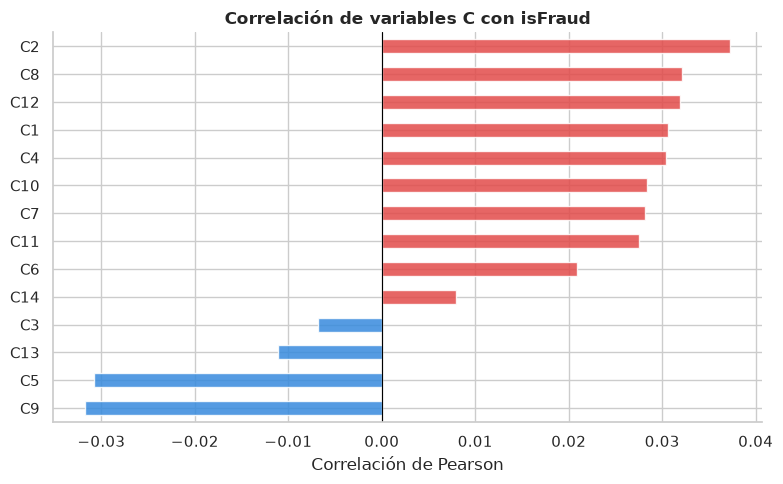

Top 5 variables C más correlacionadas con fraude
C2     0.037229
C8     0.032139
C12    0.031905
C9     0.031703
C5     0.030754
Name: isFraud, dtype: float64


In [5]:
# ------------------------------------------------------------------
# Variables C: Conteos Transaccionales
# Las variables C representan conteos asociados al comportamiento
# transaccional de la tarjeta. Análisis de correlación con el target
# ------------------------------------------------------------------
corr_c = df[c_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').sort_values()

fig = plt.figure(figsize=(8, 5))
corr_c.plot(kind='barh',
            color=[graficos.ROJO if v > 0 else graficos.AZUL for v in corr_c.values],
            alpha=0.85)

plt.axvline(0, color='black', lw=0.8)
plt.title('Correlación de variables C con isFraud')
plt.xlabel('Correlación de Pearson')
sns.despine()
plt.tight_layout()
graficos.guardar(fig, '02_variables_c')
plt.show()

print('Top 5 variables C más correlacionadas con fraude')
print(corr_c.abs().sort_values(ascending=False).head())

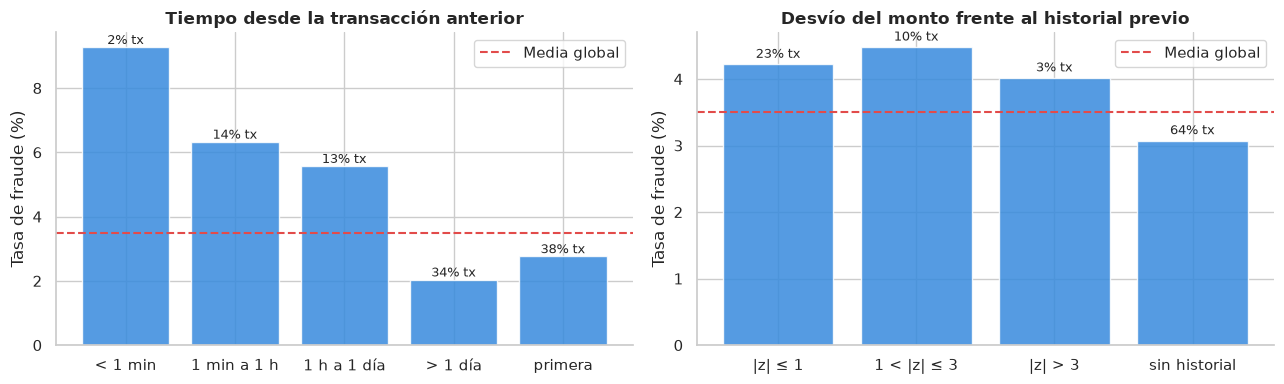


Tiempo desde la anterior
                    transacciones  tasa_fraude
seg_desde_anterior                            
< 1 min                     10624         9.27
1 min a 1 h                 82544         6.33
1 h a 1 día                 76936         5.57
> 1 día                    197943         2.04
primera                    222493         2.76

Desvío del monto
                transacciones  tasa_fraude
z_monto_previo                            
|z| ≤ 1                134341         4.22
1 < |z| ≤ 3             59794         4.48
|z| > 3                 15946         4.01
sin historial          380459         3.07


In [6]:
# ------------------------------------------------------------------
# Variables de comportamiento construidas en SQL
# Tasa de fraude según el tiempo desde la transacción anterior de la
# misma tarjeta y según el desvío del monto frente a su historial
# ------------------------------------------------------------------
tramos_tiempo = pd.cut(df['seg_desde_anterior'],
                       bins=[-np.inf, 60, 3600, 86400, np.inf],
                       labels=['< 1 min', '1 min a 1 h', '1 h a 1 día', '> 1 día'])
tramos_tiempo = tramos_tiempo.cat.add_categories('primera').fillna('primera')
tramos_z = pd.cut(df['z_monto_previo'].abs(), bins=[-np.inf, 1, 3, np.inf],
                  labels=['|z| ≤ 1', '1 < |z| ≤ 3', '|z| > 3'])
tramos_z = tramos_z.cat.add_categories('sin historial').fillna('sin historial')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tramos, titulo in [(axes[0], tramos_tiempo, 'Tiempo desde la transacción anterior'),
                           (axes[1], tramos_z, 'Desvío del monto frente al historial previo')]:
    resumen = df.groupby(tramos, observed=True)['isFraud'].agg(['mean', 'size'])
    ax.bar(resumen.index.astype(str), resumen['mean'] * 100, color=graficos.AZUL, alpha=0.85)
    ax.axhline(df['isFraud'].mean()*100, color=graficos.ROJO, linestyle='--', lw=1.5,
               label='Media global')
    for i, (tasa, n) in enumerate(zip(resumen['mean'], resumen['size'])):
        ax.text(i, tasa * 100 + 0.1, f'{n/len(df)*100:.0f}% tx', ha='center', fontsize=9)
    ax.set_title(titulo)
    ax.set_ylabel('Tasa de fraude (%)')
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
graficos.guardar(fig, '02_features_sql')
plt.show()

for nombre, tramos in [('Tiempo desde la anterior', tramos_tiempo), ('Desvío del monto', tramos_z)]:
    tabla = df.groupby(tramos, observed=True)['isFraud'].agg(transacciones='size', tasa_fraude='mean')
    tabla['tasa_fraude'] = (tabla['tasa_fraude'] * 100).round(2)
    print(f"\n{nombre}\n{tabla.to_string()}")

## Conclusiones del EDA

### 1. Nulos
214 de 434 columnas superan el umbral del 50% de nulos, concentradas principalmente en variables de identidad (id_24, id_07, id_33) y temporales (D6, D7, D12 a D14). Estas columnas se excluirán del pipeline, ya que imputarlas introduciría ruido artificial en más del 50% de los registros. Un caso particular son las 40 columnas de la tabla identity, que quedan todas excluidas porque solo el 24.4% de las transacciones tiene registro de identidad (Query 4 del notebook 01); por esta razón su información entra al modelo únicamente a través de la bandera `tiene_identidad` construida en SQL. Adicionalmente, en el modelo el umbral se vuelve a calcular solo con el periodo de entrenamiento, para que la decisión no dependa de los datos de validación ni de prueba.

### 2. Temporalidad
La hora del día es la variable temporal más informativa, ya que la tasa de fraude alcanza su pico en la hora relativa 7 (10.61%), triplicando la media global del 3.5%. Sin embargo, como TransactionDT es un delta en segundos desde una referencia desconocida (Vesta Corporation, 2019), esa hora no corresponde necesariamente a las 7 AM. Lo que sí muestra el gráfico es que el pico de fraude coincide con las horas de menor volumen, entre las horas relativas 6 y 10, que concentran entre el 0.42% y el 1.02% de las transacciones cada una, lo que sugiere que el fraude ocurre preferentemente en horas de baja actividad, que en el comercio electrónico suelen ser las de la madrugada. A medida que la actividad crece (horas relativas 12 a 17) la tasa cae por debajo de la media.

Por día de la semana la variación es mínima, teniendo en cuenta que todos los días están entre 3.15% y 3.72%, cerca de la media global, y además no se sabe qué día de la semana corresponde al día 0. La hora del día es significativamente más informativa que el día de la semana.

### 3. Distribución de montos
En escala normal ambas distribuciones son prácticamente idénticas, confirmando que el monto absoluto no discrimina bien el fraude. En escala logarítmica la diferencia está en la forma: las transacciones legítimas se concentran en unos pocos montos muy repetidos ($59, $117 y $107.95 suman el 14.5% de ellas), mientras que el fraude se distribuye de forma más dispersa y tiene mayor presencia en los extremos, con el 22.2% de los fraudes por debajo de $32 frente al 16.1% de las legítimas, y el 8.1% por encima de $402 frente al 5.5%. TransactionAmt se transformará con log1p en el pipeline.

### 4. Variables C
Las correlaciones individuales son bajas (máximo 0.037 para C2), sin embargo existe una separación clara entre variables positivamente correlacionadas con fraude (C2, C8, C12, C1, C4) y negativamente correlacionadas (C9, C5). Todas se conservan en el pipeline.

### 5. Variables de comportamiento construidas en SQL
El tiempo desde la transacción anterior de la misma tarjeta es la variable SQL con la señal más clara: cuando la transacción ocurre menos de un minuto después de la anterior, la tasa de fraude es de 9.27%, y baja a medida que aumenta el intervalo hasta 2.04% cuando pasa más de un día. En cambio, el desvío del monto frente al historial previo apenas separa el riesgo (entre 4.01% y 4.48% en los tres tramos con historial), lo que coincide con la Query 3 del notebook 01, en el sentido de que un monto inusual para la tarjeta no es por sí solo señal de fraude. Adicionalmente, el 64% de las transacciones no tiene historial suficiente para calcular el z-score, por lo que su aporte, si existe, se dará en combinación con otras variables dentro del modelo.

### Decisiones para el pipeline
- Excluir columnas con >50% nulos, calculando el umbral solo sobre el periodo de entrenamiento
- Crear las variables "hora" y "dia_semana" derivadas de TransactionDT, entendidas como relativas
- Aplicar transformación log1p a TransactionAmt y a los montos de las variables SQL
- Conservar todas las variables C para el modelo
- Incorporar las 9 variables de comportamiento construidas en SQL
- Manejar el desbalance de clases con scale_pos_weight en XGBoost e is_unbalance en LightGBM

## Referencias

- Vesta Corporation. (2019). *Data description (details and discussion)* [Publicación en foro]. Kaggle. https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203